In [1]:
using FFTW
using GLMakie

In [2]:
function read_test(file)
    vals = map(x -> parse(Int32,x[1]) + 1im*parse(Int32,x[2]),split.(readlines(file),", "))
    return vals
end

read_test (generic function with 1 method)

In [3]:
ramp_cp = read_test("../OFDM_SDR/ramp_out.txt");

In [4]:
function bin_map(k0, M, P, N)
    k_first = k0 - 1
    k_last = k0 + M + P
    bin_map = zeros(Int8,N)
    pilots = floor.(Int,(k_first.+((1:P)*(k_last-k_first))/(P+1)))
    bin_map[(k_first+1):(k_last+1)] .= 1
    bin_map[pilots.+1] .= 2
    bin_map[k_first+1] = 2
    bin_map[k_last+1] = 2
    return bin_map
end
k0 = 22
M = 256
P = 8
N = 1024
CP = 8
bins = bin_map(k0,M,P,N);
ramp = ramp_cp[CP+1:end]
ramp_fft = fft(ramp);
slope = 262143
expected = zeros(N)
cnt = 0
for i in 1:N
    if bins[i] == 0
        expected[i] = 0
    elseif bins[i] == 1
        expected[i] = cnt*slope
        cnt = cnt + 1
    else
        expected[i] = 759250125
    end
end
expected_C = expected + 1im*expected;
EVM(X,X_hat) = sqrt(sum(abs2.(X-X_hat))/(sum(abs2.(X))))
gain(X,X_hat) = sum(conj.(X_hat).*X)/(sum(abs2.(X)))
EVM_g(X,X_hat) = sqrt(sum(abs2.(X-(gain(X,X_hat)*X_hat)))/(sum(abs2.(X))))
EVM(ramp_fft,expected_C), gain(ramp_fft,expected_C), EVM_g(ramp_fft,expected_C)

(0.00012007855510133443, 1.0001122884974831 + 1.5411203687426996e-8im, 0.0002285848838185226)

In [5]:
data_ramp_fft = ramp_fft[ones(Int,N) .== bins]
data_expected = expected_C[ones(Int,N) .== bins]
EVM(data_ramp_fft,data_expected),gain(data_ramp_fft,data_expected), EVM_g(data_ramp_fft,data_expected)

(0.00013685227223039464, 1.0001270760546976 + 9.701670697295552e-8im, 0.00025919562181753)

In [6]:
pilot_ramp_fft = ramp_fft[ones(Int,N)*2 .== bins]
pilot_expected = expected_C[ones(Int,N)*2 .== bins]
EVM(pilot_ramp_fft,pilot_expected),gain(pilot_ramp_fft,pilot_expected), EVM_g(pilot_ramp_fft,pilot_expected)

(0.00011759271648952492, 1.0001113087728108 + 1.000288425080009e-8im, 0.00022583802220722278)

In [7]:
guard_ramp_fft = ramp_fft[ones(Int,N)*0 .== bins]
sqrt(sum(abs2.(guard_ramp_fft))/length(guard_ramp_fft))/ (2^31 - 1)

1.0031688376820696e-6

In [8]:
active_ramp_fft = ramp_fft[bins .> 0]
leak_ratio = sqrt(sum(abs2.(guard_ramp_fft)) / sum(abs2.(active_ramp_fft)))

1.6918138225833916e-5

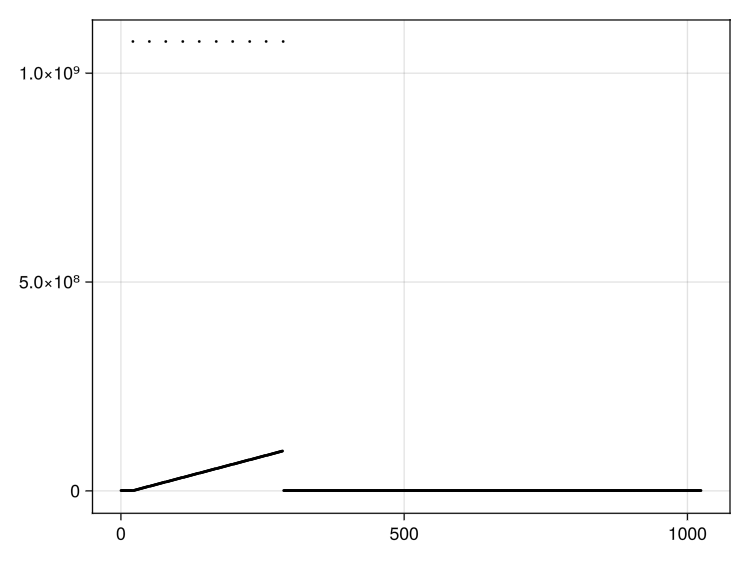

In [9]:
scatter(abs.(fft(ramp)),markersize=3,color=:black)

In [10]:
dB(x)=20*log10(x)
dB(leak_ratio)

-95.43294862113443

In [11]:
dB(EVM(ramp_fft,expected_C)),dB(EVM(data_ramp_fft,data_expected)),dB(EVM(pilot_ramp_fft,pilot_expected)),
dB(leak_ratio)

(-78.41069093150038, -77.27495974747691, -78.59239153906967, -95.43294862113443)